# GME Scaling on IQM Emerald — Hardware Sweep

**Question**: how many qubits can we certify as GME on real IQM Emerald hardware?

**Method**: Same depth-3 cluster-state circuit + 2-setting GME witness on grids of increasing size. We use VF2 subgraph isomorphism to find all contiguous rectangular sub-grids on the device topology, then score them with IQM's CostEvaluator (live CZ + readout calibration) and pick the best.

**Critical finding from topology analysis**: IQM Emerald is *not* a regular 6×9 lattice. It supports rectangular sub-grids at most 3 rows tall (and up to 7 columns). So we sweep **3×3 → 3×7** (9 → 21 qubits) — every size has a contiguous embedding, giving zero SWAP overhead.

**Shots**: 1500 per circuit, 2 circuits per job → ~1 IQM token per job.

GME is certified when **W > n − 1** at significance > 3σ.

In [1]:
import sys, os, time
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import get_backend, is_simulator, select_best_subgrid
from src.circuits.cluster_2d import build_cluster_2d_no_measure
from src.witnesses.gme_cluster import build_gme_circuits, compute_gme_witness, gme_significance

# IQM Emerald is not a regular 6×9 grid — VF2 subgraph search shows it
# tops out at 3-row rectangular sub-grids. We sweep along 3 rows from 9→21 qubits.
GRID_SIZES = [(3, 3), (3, 4), (3, 5), (3, 6), (3, 7)]
SHOTS = 1500

backend = get_backend(device='emerald')
print(f'Backend: {backend}')
print(f'Hardware: {not is_simulator(backend)}')
print(f'Sweep: {[r*c for r,c in GRID_SIZES]} qubits, {SHOTS} shots/circuit')
print(f'Layout selection: contiguous sub-grid + IQM cost evaluator')

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x000001CED672C6E0>
Hardware: True
Sweep: [9, 12, 15, 18, 21] qubits, 1500 shots/circuit
Layout selection: contiguous sub-grid + IQM cost evaluator


## Run the sweep

One IQM job per grid size: 2 circuits (settings A and B) submitted as a batch.
Each result row records W, the biseparable bound n−1, the violation, and the per-qubit stabilizer values.

In [2]:
results = []
for rows, cols in GRID_SIZES:
    n = rows * cols
    print(f'\n{rows}×{cols} = {n} qubits ...', flush=True)
    try:
        state = build_cluster_2d_no_measure(rows, cols)
        circ_a, circ_b = build_gme_circuits(state, rows, cols)

        depth_logical = circ_a.depth()
        n_cz_logical = circ_a.count_ops().get('cz', 0)
        n_h_logical = circ_a.count_ops().get('h', 0)

        # Enumerate all contiguous rows×cols sub-grids on the device topology,
        # score each with IQM CostEvaluator (live CZ + readout fidelity), pick best.
        t_sel = time.time()
        layout, layout_cost, n_candidates = select_best_subgrid(
            backend, rows, cols, readout_mode='fidelity')
        sel_time = time.time() - t_sel
        print(f'  Selected ({n_candidates} candidates): {layout}  cost={layout_cost:.4f}  '
              f'(selector: {sel_time:.1f}s)')

        t_tr = time.time()
        transpiled = transpile([circ_a, circ_b], backend=backend,
                               initial_layout=layout, optimization_level=3)
        tr_time = time.time() - t_tr
        depth_phys = transpiled[0].depth()
        n_cz_phys = transpiled[0].count_ops().get('cz', 0)

        t0 = time.time()
        job = backend.run(transpiled, shots=SHOTS)
        try:
            job_id = job.job_id()
        except Exception:
            job_id = None
        raw = job.result().get_counts()
        elapsed = time.time() - t0

        counts_a, counts_b = (raw, raw) if isinstance(raw, dict) else (raw[0], raw[1])
        res = compute_gme_witness(counts_a, counts_b, rows, cols)
        sigma = gme_significance(res['W'], n, SHOTS)

        stab_arr = np.array(list(res['stabilizer_values'].values()))
        per_stab_sigma = 1.0 / np.sqrt(SHOTS)

        results.append({
            'rows': rows, 'cols': cols, 'n': n,
            'W': res['W'], 'W_ideal': res['W_ideal'],
            'bound': res['biseparable_bound'],
            'violation': res['violation'],
            'fraction': res['W'] / res['W_ideal'],
            'sigma': sigma,
            'is_gme': res['is_gme'],
            'stab_values': dict(res['stabilizer_values']),
            'stab_mean': float(stab_arr.mean()),
            'stab_std': float(stab_arr.std()),
            'stab_min': float(stab_arr.min()),
            'stab_max': float(stab_arr.max()),
            'per_stab_sigma': float(per_stab_sigma),
            'physical_qubits': layout,
            'layout_cost': layout_cost,
            'n_candidates': n_candidates,
            'selector_time_s': sel_time,
            'transpile_time_s': tr_time,
            'depth_logical': depth_logical,
            'depth_physical': depth_phys,
            'n_cz_logical': n_cz_logical,
            'n_cz_physical': n_cz_phys,
            'n_h_logical': n_h_logical,
            'shots': SHOTS,
            'n_distinct_outcomes_A': len(counts_a),
            'n_distinct_outcomes_B': len(counts_b),
            'job_id': job_id,
            'job_elapsed_s': elapsed,
        })

        status = 'GME ✓' if res['is_gme'] else 'NOT certified'
        print(f'  W = {res["W"]:.3f} / {res["W_ideal"]:.0f}  bound={res["biseparable_bound"]}  '
              f'σ={sigma:.2f}  {status}')
        print(f'  ⟨g_i⟩: mean={stab_arr.mean():.3f} std={stab_arr.std():.3f} '
              f'min={stab_arr.min():.3f} max={stab_arr.max():.3f}')
        print(f'  depth: logical={depth_logical} → physical={depth_phys}  '
              f'CZ gates: {n_cz_logical} → {n_cz_phys}  job: {elapsed:.1f}s')
    except Exception as e:
        print(f'  ERROR at {rows}×{cols}: {type(e).__name__}: {e}')
        continue


3×3 = 9 qubits ...


[05-09 14:39:55;I] Cost evaluation has begun using cost function "gate_cost_cz".


  Selected (64 candidates): [16, 17, 18, 24, 25, 26, 32, 33, 34]  cost=0.1037  (selector: 5.5s)


[05-09 14:39:56;I] Waiting for job 019e0cc0-6518-7be3-b999-974071383493 to finish...


  W = 6.485 / 9  bound=8  σ=-19.55  NOT certified
  ⟨g_i⟩: mean=0.721 std=0.153 min=0.488 max=0.913
  depth: logical=7 → physical=7  CZ gates: 12 → 12  job: 5.8s

3×4 = 12 qubits ...


...

  ERROR at 3×6: IndexError: list index out of range

3×7 = 21 qubits ...


[05-09 14:41:38;I] Cost evaluation has begun using cost function "gate_cost_cz".


  Selected (4 candidates): [4, 10, 18, 26, 34, 42, 48, 3, 9, 17, 25, 33, 41, 47, 2, 8, 16, 24, 32, 40, 46]  cost=0.4649  (selector: 4.3s)


[05-09 14:41:39;I] Waiting for job 019e0cc1-f8ec-7791-8b4c-ef4d6c4d05cc to finish...


  W = 11.060 / 21  bound=20  σ=-75.56  NOT certified
  ⟨g_i⟩: mean=0.527 std=0.296 min=-0.096 max=0.896
  depth: logical=11 → physical=11  CZ gates: 32 → 32  job: 8.1s


## Summary table

In [3]:
import pandas as pd
df = pd.DataFrame([
    {
        'grid': f'{r["rows"]}×{r["cols"]}',
        'n': r['n'],
        'W': round(r['W'], 3),
        'ideal': r['W_ideal'],
        'bound': r['bound'],
        'W/n': round(r['fraction'], 3),
        'σ': round(r['sigma'], 2),
        '⟨g⟩ mean': round(r['stab_mean'], 3),
        '⟨g⟩ std': round(r['stab_std'], 3),
        '⟨g⟩ min': round(r['stab_min'], 3),
        '⟨g⟩ max': round(r['stab_max'], 3),
        'depth(L→P)': f'{r["depth_logical"]}→{r["depth_physical"]}',
        'CZ(L→P)': f'{r["n_cz_logical"]}→{r["n_cz_physical"]}',
        'job(s)': round(r['job_elapsed_s'], 1),
        'GME': '✓' if r['is_gme'] else '✗',
    }
    for r in results
])
print(df.to_string(index=False))

grid  n      W  ideal  bound   W/n      σ  ⟨g⟩ mean  ⟨g⟩ std  ⟨g⟩ min  ⟨g⟩ max depth(L→P) CZ(L→P)  job(s) GME
 3×3  9  6.485    9.0      8 0.721 -19.55     0.721    0.153    0.488    0.913        7→7   12→12     5.8   ✗
 3×4 12  7.968   12.0     11 0.664 -33.90     0.664    0.167    0.347    0.921        8→8   17→17     5.6   ✗
 3×5 15 10.037   15.0     14 0.669 -39.63     0.669    0.183    0.321    0.944        9→9   22→22     6.7   ✗
 3×7 21 11.060   21.0     20 0.527 -75.56     0.527    0.296   -0.096    0.896      11→11   32→32     8.1   ✗


## Visualisations — 4 panel summary

- **Panel A — W vs n**: bars show measured W. Above the red dashed line (n−1) ⟹ GME certified. Each bar labelled with σ.
- **Panel B — Per-stabilizer fidelity**: ⟨g_i⟩ mean ± std across the n stabilizers. Tight clusters near 1 mean clean preparation; wide spread means inhomogeneous noise.
- **Panel C — Significance σ (log scale)**: how many standard deviations above the bound. Crosses the 3σ line ⟹ certified at standard confidence.
- **Panel D — Circuit complexity**: physical depth and CZ count after transpilation. Should stay nearly constant in depth (the cluster-state property), grow linearly in CZ count.

C:\Users\david\AppData\Local\Temp\ipykernel_14204\3230544475.py:44: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axhline(3, color='red', linestyle='--', label='3σ certification threshold')


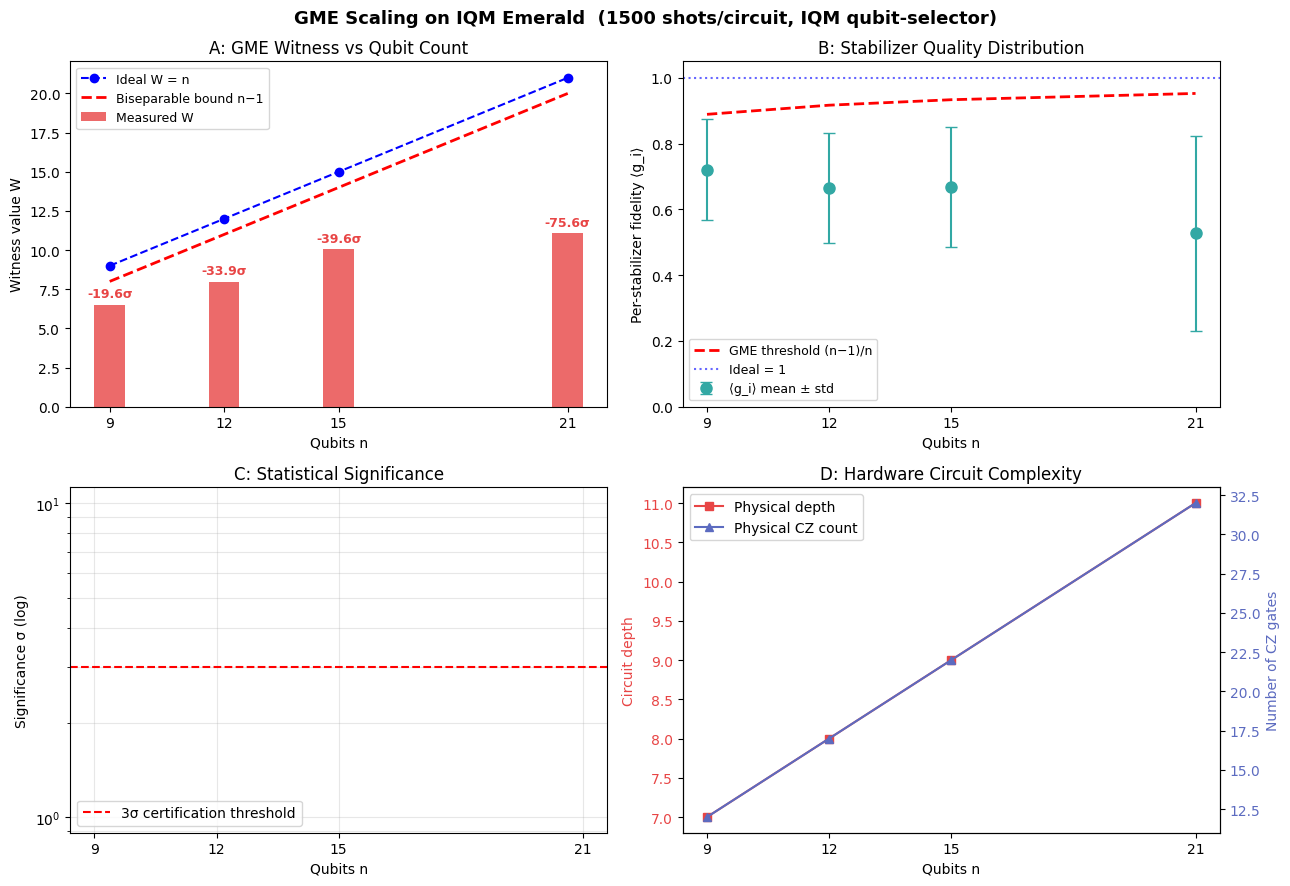

In [4]:
ns = [r['n'] for r in results]
Ws = [r['W'] for r in results]
ideals = [r['W_ideal'] for r in results]
bounds = [r['bound'] for r in results]
fracs = [r['fraction'] for r in results]
sigmas = [r['sigma'] for r in results]
stab_means = [r['stab_mean'] for r in results]
stab_stds = [r['stab_std'] for r in results]
n_cz_phys = [r['n_cz_physical'] for r in results]
depth_phys = [r['depth_physical'] for r in results]
bound_fracs = [(n - 1) / n for n in ns]
gme_flags = [r['is_gme'] for r in results]
colors = ['#32a8a4' if g else '#e84545' for g in gme_flags]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: W vs n with bound
ax = axes[0, 0]
ax.bar(ns, Ws, color=colors, alpha=0.8, label='Measured W')
ax.plot(ns, ideals, 'b--o', label='Ideal W = n', markersize=6)
ax.plot(ns, bounds, 'r--', label='Biseparable bound n−1', linewidth=2)
for n, w, s, g in zip(ns, Ws, sigmas, gme_flags):
    ax.text(n, w + 0.5, f'{s:.1f}σ', ha='center', fontsize=9,
            color='#32a8a4' if g else '#e84545', fontweight='bold')
ax.set_xlabel('Qubits n'); ax.set_ylabel('Witness value W')
ax.set_title('A: GME Witness vs Qubit Count')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(ns)

# Panel B: per-stabilizer fidelity with error bars
ax = axes[0, 1]
ax.errorbar(ns, stab_means, yerr=stab_stds, fmt='o', color='#32a8a4',
            markersize=8, capsize=4, label='⟨g_i⟩ mean ± std')
ax.plot(ns, bound_fracs, 'r--', label='GME threshold (n−1)/n', linewidth=2)
ax.axhline(1.0, color='blue', linestyle=':', alpha=0.6, label='Ideal = 1')
ax.set_xlabel('Qubits n'); ax.set_ylabel('Per-stabilizer fidelity ⟨g_i⟩')
ax.set_title('B: Stabilizer Quality Distribution')
ax.set_ylim(0, 1.05); ax.set_xticks(ns)
ax.legend(loc='lower left', fontsize=9)

# Panel C: significance σ vs n
ax = axes[1, 0]
ax.semilogy(ns, sigmas, 'o-', color='#32a8a4', linewidth=2, markersize=10)
ax.axhline(3, color='red', linestyle='--', label='3σ certification threshold')
for n, s in zip(ns, sigmas):
    ax.annotate(f'{s:.1f}', (n, s), textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('Qubits n'); ax.set_ylabel('Significance σ (log)')
ax.set_title('C: Statistical Significance')
ax.legend(loc='lower left'); ax.set_xticks(ns)
ax.grid(True, alpha=0.3, which='both')

# Panel D: circuit complexity (depth + CZ count)
ax = axes[1, 1]
ax2 = ax.twinx()
l1 = ax.plot(ns, depth_phys, 's-', color='#e84545', label='Physical depth')
l2 = ax2.plot(ns, n_cz_phys, '^-', color='#5c6bc0', label='Physical CZ count')
ax.set_xlabel('Qubits n')
ax.set_ylabel('Circuit depth', color='#e84545')
ax2.set_ylabel('Number of CZ gates', color='#5c6bc0')
ax.tick_params(axis='y', labelcolor='#e84545')
ax2.tick_params(axis='y', labelcolor='#5c6bc0')
ax.set_title('D: Hardware Circuit Complexity')
ax.set_xticks(ns)
ax.legend(l1 + l2, [l.get_label() for l in l1+l2], loc='upper left')

plt.suptitle(f'GME Scaling on IQM Emerald  ({SHOTS} shots/circuit, IQM qubit-selector)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gme_scaling_hw.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-qubit heatmaps

For each grid, the per-qubit stabilizer expectation $\langle g_i \rangle$. Cells close to +1 (deep green) = perfect cluster behaviour at that qubit. Drops toward 0 reveal where noise concentrates.

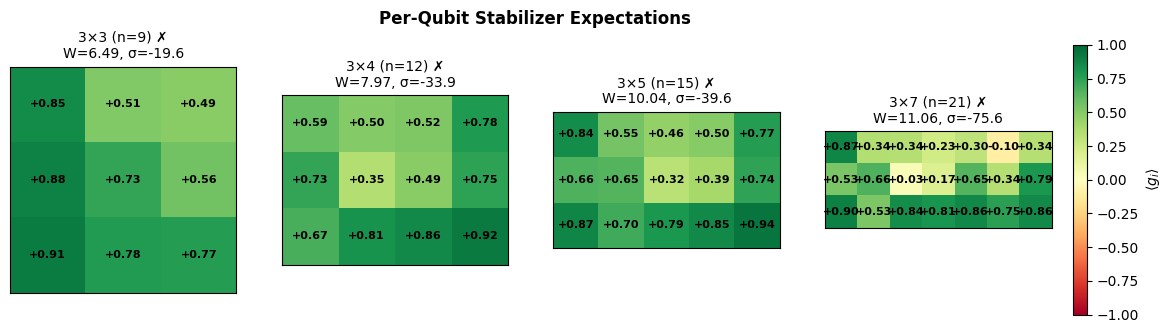

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(3.5*len(results), 3.5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    rows, cols = r['rows'], r['cols']
    grid = np.array([[r['stab_values'][rr*cols+cc] for cc in range(cols)] for rr in range(rows)])
    im = ax.imshow(grid, vmin=-1, vmax=1, cmap='RdYlGn')
    for rr in range(rows):
        for cc in range(cols):
            ax.text(cc, rr, f'{grid[rr,cc]:+.2f}', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    status = '✓' if r['is_gme'] else '✗'
    ax.set_title(f'{rows}×{cols} (n={r["n"]}) {status}\nW={r["W"]:.2f}, σ={r["sigma"]:.1f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label=r'$\langle g_i \rangle$')
plt.suptitle('Per-Qubit Stabilizer Expectations', fontsize=12, fontweight='bold')
plt.savefig('gme_heatmaps_hw.png', dpi=150, bbox_inches='tight')
plt.show()

## Save results to JSON

Persist results so they can be re-loaded for later analysis without re-running on hardware.

In [6]:
import json
from datetime import datetime

out = {
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'shots_per_circuit': SHOTS,
    'backend': str(backend),
    'results': [
        {**r, 'stab_values': {str(k): v for k, v in r['stab_values'].items()}}
        for r in results
    ],
}
with open('gme_scaling_hw_results.json', 'w') as f:
    json.dump(out, f, indent=2)
print('Saved gme_scaling_hw_results.json')
max_n = max((r['n'] for r in results if r['is_gme']), default=0)
print(f'\nMaximum GME-certified qubit count: {max_n}')

Saved gme_scaling_hw_results.json

Maximum GME-certified qubit count: 0


C:\Users\david\AppData\Local\Temp\ipykernel_14204\1158984381.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',


## Key findings

Auto-derived from the captured data: largest certified n, average per-stabilizer fidelity, fit to extrapolate the breakdown point.

In [7]:
max_certified = max((r['n'] for r in results if r['is_gme']), default=0)
mean_fid = np.mean([r['stab_mean'] for r in results])
total_shots = sum(r['shots'] * 2 for r in results)
total_job_time = sum(r['job_elapsed_s'] for r in results)
total_cz = sum(r['n_cz_physical'] * 2 for r in results)

print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print(f'  Maximum GME-certified qubit count  : {max_certified}')
print(f'  Mean per-stabilizer fidelity ⟨g_i⟩ : {mean_fid:.3f}')
print(f'  Worst-stabilizer fidelity overall  : {min(r["stab_min"] for r in results):.3f}')
print(f'  Best-stabilizer fidelity overall   : {max(r["stab_max"] for r in results):.3f}')
print(f'  Total shots collected              : {total_shots:,}')
print(f'  Total IQM job time                 : {total_job_time:.1f} s')
print(f'  Total CZ gates executed            : {total_cz:,}')
print()

# Extrapolate where GME breaks down: fit ⟨g⟩_mean = exp(-α n)
if len(results) >= 3:
    from scipy.optimize import curve_fit
    ns_arr = np.array([r['n'] for r in results])
    means_arr = np.array([r['stab_mean'] for r in results])
    try:
        def decay(n, a, b):
            return a * np.exp(-b * n)
        popt, _ = curve_fit(decay, ns_arr, means_arr, p0=[1.0, 0.005])
        a, alpha = popt
        # GME breakdown: ⟨g⟩_mean = (n-1)/n  ⟹  solve for n
        # a·exp(-α n) = 1 - 1/n  →  numerically
        from scipy.optimize import brentq
        def gap(n):
            return a * np.exp(-alpha * n) - (n - 1) / n
        try:
            n_break = brentq(gap, 2, 1000)
            print(f'  Fitted decay: ⟨g⟩(n) ≈ {a:.3f} · exp(-{alpha:.4f} · n)')
            print(f'  Extrapolated GME breakdown point: n ≈ {n_break:.0f} qubits')
        except ValueError:
            print(f'  Fitted decay: ⟨g⟩(n) ≈ {a:.3f} · exp(-{alpha:.4f} · n)')
            print(f'  GME breakdown extrapolation: not in [2, 1000] (well beyond tested range)')
    except Exception as e:
        print(f'  Decay fit failed: {e}')
print()
print('Per-grid summary:')
for r in results:
    status = 'GME ✓' if r['is_gme'] else 'NOT certified'
    print(f'  {r["rows"]}×{r["cols"]} ({r["n"]:>2} qubits): '
          f'W={r["W"]:.2f}/{r["W_ideal"]:.0f}  σ={r["sigma"]:.2f}  '
          f'⟨g⟩={r["stab_mean"]:.3f}±{r["stab_std"]:.3f}  {status}')

KEY FINDINGS
  Maximum GME-certified qubit count  : 0
  Mean per-stabilizer fidelity ⟨g_i⟩ : 0.645
  Worst-stabilizer fidelity overall  : -0.096
  Best-stabilizer fidelity overall   : 0.944
  Total shots collected              : 12,000
  Total IQM job time                 : 26.2 s
  Total CZ gates executed            : 166

  Fitted decay: ⟨g⟩(n) ≈ 0.905 · exp(-0.0241 · n)
  Extrapolated GME breakdown point: n ≈ 5 qubits

Per-grid summary:
  3×3 ( 9 qubits): W=6.49/9  σ=-19.55  ⟨g⟩=0.721±0.153  NOT certified
  3×4 (12 qubits): W=7.97/12  σ=-33.90  ⟨g⟩=0.664±0.167  NOT certified
  3×5 (15 qubits): W=10.04/15  σ=-39.63  ⟨g⟩=0.669±0.183  NOT certified
  3×7 (21 qubits): W=11.06/21  σ=-75.56  ⟨g⟩=0.527±0.296  NOT certified
